# Super-Point Computation


> **Inputs:**
> - Wave spectra in `.nc` format from CAWCR or ERA5.  
>   These can optionally include prior satellite correction.
>
> **Outputs:**
> - `superPoint.nc`: reconstructed offshore spectrum saved in the `outputs` folder.  
>   Used as input for BinWaves **Reconstruction** and later **Validation**.



To account for all possible wave energy and avoid the shadowing effect caused by land, a **Super-Point** is created. This approach, proposed by Cagigal et al. (2021), aggregates energy from multiple surrounding points near the study site.

<center>
    <img src="./assets/superPoint.png" width="80%">
</center>

In this case, the virtual **Super-Point** is constructed using two directional spectra from the CAWCR (Centre for Australian Weather and Climate Research) hindcast dataset (Durrant et al., 2014; Smith et al., 2020).


In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import os.path as op
import sys
import xarray as xr
import numpy as np

In [2]:
files = [
    'inputs/1903941_spec_WHACS_15D.nc',
    'inputs/grid1_41013_spec_WHACS_buoy_correted_15D.nc',
]
def load_station_data(ds: xr.Dataset) -> xr.Dataset:
    return ds.expand_dims("station")

# Use xr.open_mfdataset
stations_data = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim="station",
    preprocess=load_station_data,
).rename({'__xarray_dataarray_variable__': 'efth'})

# Define the actual station IDs
station_ids = [1903941,1903381]

# Replace the sequential station coordinates with actual station IDs
stations_data = stations_data.assign_coords(station=station_ids)
stations_data = stations_data.compute() 
stations_data

<xarray.Dataset> Size: 4GB
Dimensions:   (station: 2, time: 394464, freq: 29, dir: 24)
Coordinates:
  * time      (time) datetime64[ns] 3MB 1979-01-01 ... 2023-12-31T23:00:00
  * freq      (freq) float64 232B 0.035 0.03849 0.04232 ... 0.4135 0.4547 0.5
  * dir       (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    seapoint  int32 4B 1903941
  * station   (station) int64 16B 1903941 1903381
Data variables:
    efth      (station, time, freq, dir) float64 4GB nan nan ... 1.069e-09

In [3]:
import importlib
import bluemath_tk.waves.superpoint 
importlib.reload(bluemath_tk.waves.superpoint)
from bluemath_tk.waves.superpoint import superpoint_calculation

sectors_for_each_station = {}
stations_id = [1903941,1903381]
stations_sector = [(300,120), (120, 300)]

for i, station_id in enumerate(stations_data.station.values):
    sectors_for_each_station[station_id] = stations_sector[i]

superpoint_result = superpoint_calculation(
    stations_data=stations_data,
    stations_dimension_name='station',
    sectors_for_each_station=sectors_for_each_station,
    overlap_angle=22.5,
)
# Virtual Coodinates
superpoint_result['latitude'] = 33.8928
superpoint_result['longitude'] = -76.9845
superpoint_result

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 394464, freq: 29, dir: 24)
Coordinates:
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2023-12-31T23:00:00
  * freq       (freq) float64 232B 0.035 0.03849 0.04232 ... 0.4135 0.4547 0.5
  * dir        (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    seapoint   int32 4B 1903941
    station    int64 8B 1903941
Data variables:
    efth       (time, freq, dir) float64 2GB nan nan nan ... 1.888e-09 2.038e-11
    latitude   float64 8B 33.89
    longitude  float64 8B -76.98

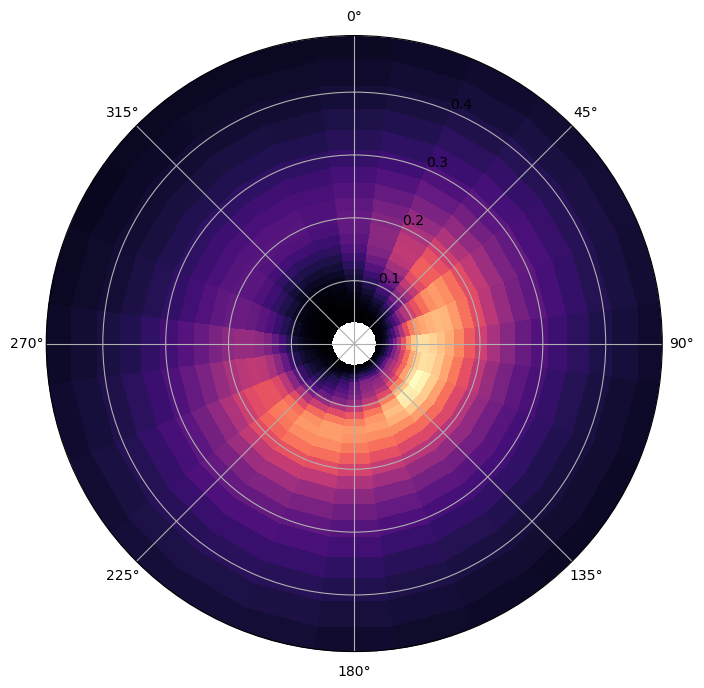

In [4]:
import importlib
import sys
sys.path.append('../utils')
from plotting import Plot_spectrum
Plot_spectrum(superpoint_result, average=True);

In [ ]:
superpoint_result.to_netcdf("inputs/grid2_superPoint_grid2_15D.nc")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from utils.plotting import haversine_km

# point of interest
point_lat = 36.2000
point_lon = -75.7140

use_buoy = False
max_distance_km = 5.0
if use_buoy:
    # find nearest buoy automatically
    buoy_ids = list(buoys.keys())
    buoy_lats = np.array([buoys[b][1] for b in buoy_ids])
    buoy_lons = np.array([buoys[b][0] for b in buoy_ids])

    buoy_dist = haversine_km(point_lat, point_lon, buoy_lats, buoy_lons)
    j = np.argmin(buoy_dist)
    nearest_buoy_id = buoy_ids[j]
    nearest_dist = float(buoy_dist[j])

    if nearest_dist <= max_distance_km:
        print(f"Nearest buoy: {nearest_buoy_id} at {nearest_dist:.2f} km")

        pkl_path = f"./inputs/buoys&tideGauges/buoy_data/buoy_{nearest_buoy_id}_bulk_parameters.pkl"
        buoy_df = pd.read_pickle(pkl_path)

        if isinstance(time_to_sample, slice):
            buoy_period = buoy_df.loc[time_to_sample.start:time_to_sample.stop]
            time_label = f"{time_to_sample.start} to {time_to_sample.stop}"
        else:
            buoy_period = buoy_df.loc[time_to_sample]
            time_label = time_to_sample

# Create subplots for Hs, Tp, and Dir
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Define variable mappings: spectrum variable -> buoy column
var_mappings = {
    "hs": ("Hs_Buoy", "Hs (m)", False),  # (buoy_col, ylabel, use_markers)
    "tp": ("Tp_Buoy", "Tp (s)", False),
    "dp": ("Dir_Buoy", "Dir (deg)", True)
}

# Plot each variable
for idx, (var_name, (buoy_col, ylabel, use_markers)) in enumerate(var_mappings.items()):
    ax = axes[idx]
    
    # Get spectrum data
    spec_data = getattr(spec_total.spec, var_name)()
    
    # Plot spectrum
    if use_markers:
        spec_data.plot(ax=ax, label="BinWaves Spectrum", color="k", linewidth=0.5, 
                      linestyle="none", marker=".", markersize=0.5)
    else:
        spec_data.plot(ax=ax, label="BinWaves Spectrum", color="k", linewidth=0.5)
    
    # Plot buoy data if available
    if use_buoy and nearest_dist <= max_distance_km and buoy_col in buoy_period.columns:
        if use_markers:
            buoy_period[buoy_col].plot(ax=ax, label=f"Buoy {nearest_buoy_id}", 
                                      color="slateblue", linewidth=1.5, 
                                      linestyle="none", marker=".", markersize=0.5)
        else:
            buoy_period[buoy_col].plot(ax=ax, label=f"Buoy {nearest_buoy_id}", 
                                      color="slateblue", linewidth=1.5)
    
    ax.set_ylabel(ylabel)
    if idx == 2:  # Last subplot
        ax.set_xlabel("Time")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-01-07"))
plt.tight_layout()
plt.show()